DO: per unit CCG around oscillations, see if some region pairs have temporality

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr

import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _unitCCG(session,regs=None,when='sleep.*#0',bin=0.05,limits=(-0.5,0.5)):

    # load data
    R = fma.regions.regions(session,phases=when,states='sws',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    events = isau.loadHpcPfcEvents(session)

    spikes = R.spikes(regs=regs)
    n_units = np.array([len(R.units(r)) for r in regs])
    unit_unique, unit_reg = R.units(regs=regs,return_reg=True)

    conditions = {'isa': R.eventIntervals('slownr'), 'nisa': R.eventIntervals([['sws','/slownr']])}
    lim_oscill = [[-1,1],[-1,1],[-3,3]]
    for i, e in enumerate(events):
        conditions[e] = events[e][:,None] + lim_oscill[i]

    ccg = []
    for condition in conditions.values():
        s = fma.general.restrict(spikes,condition)
        c, t = fma.analysis.CCG(s,bin,limits,fast=True,norm='rate')
        ccg.append(c)

    ccg = xr.DataArray(ccg,dims=['cond','reg0','reg1','t'],coords={'cond': list(conditions.keys()), 'reg0': unit_reg, 'reg1': unit_reg, 't': t, 'rat': int(R.rat)})

    return ccg

In [5]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][14]
print(session)
regs = ['hpc','nr','pfc']
ccg = _unitCCG(session,regs=regs,bin=0.005,limits=(-0.1,0.1))

/mnt/hubel-data-139/karadoc/Rat004_20240226/Rat004_20240226.xml


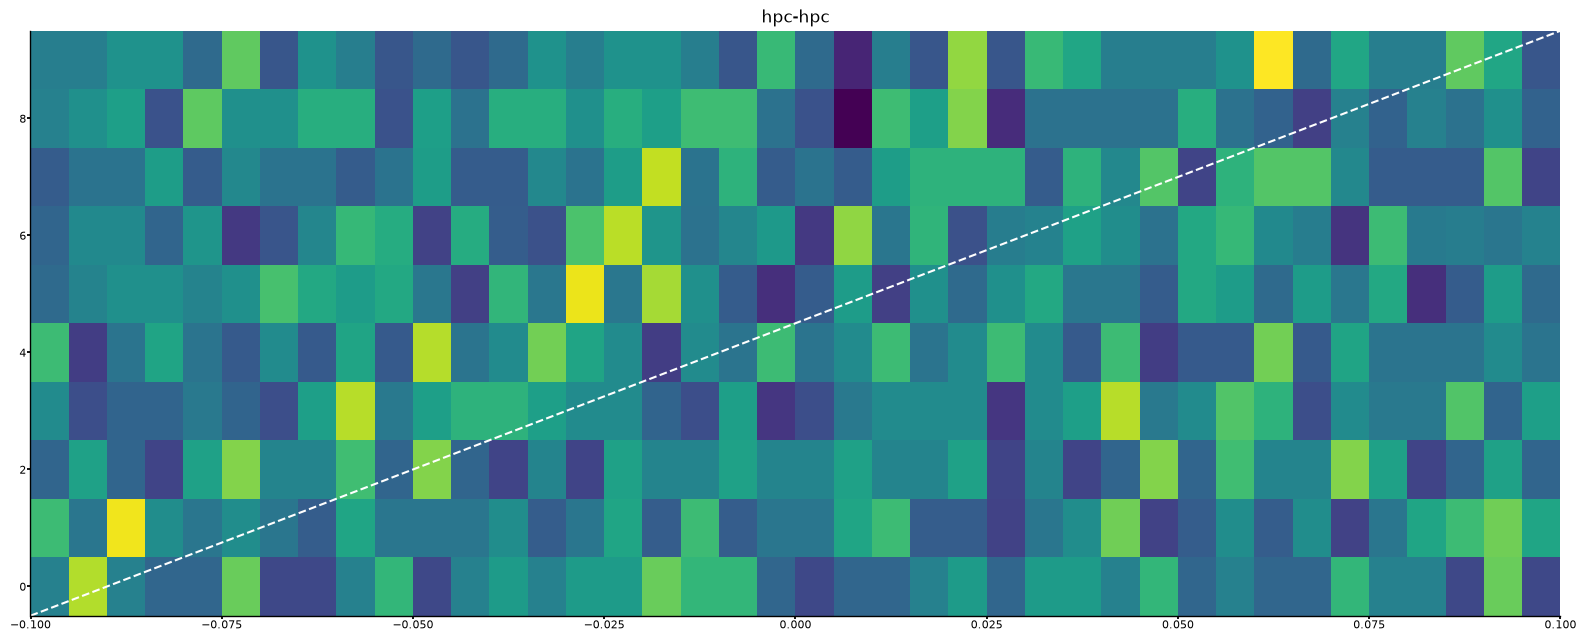

In [11]:
# note: only within-region count CCGs should satisfy t, -t symmetry
cond = 'ripples'
r0 = 'hpc'
r1 = 'hpc'
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(size=(40,16))
c = ccg.sel(cond=cond).sel(reg0=r0,reg1=r1)
c = c.values.reshape(-1,c.shape[-1])[:10]
fma.plotting.plotColorMap(c,x=ccg.t,zscore=1,omitnan=1,sortby='peak')
ax[0].plot(ax[0].get_xlim(),ax[0].get_ylim(),color='w',ls='--')
ax[0].set(title=f'{r0}-{r1}');

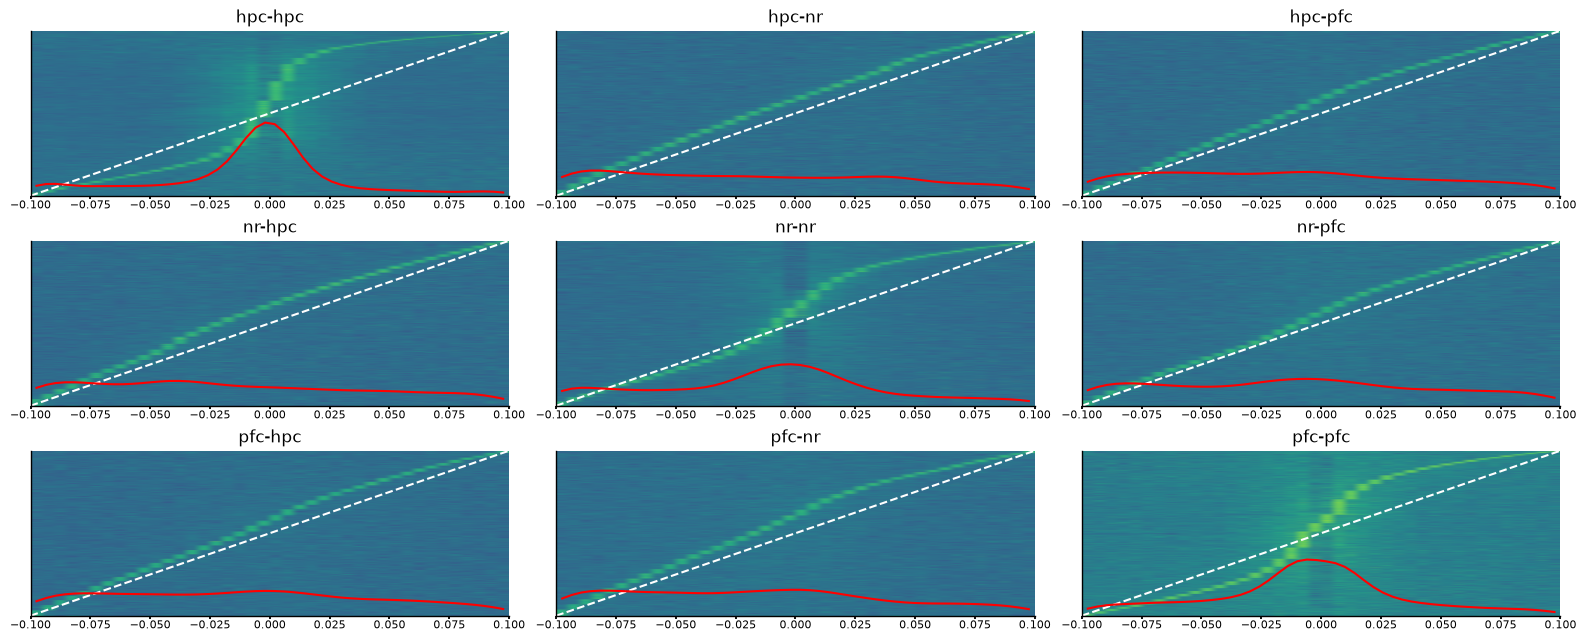

In [20]:
# note: only within-region count CCGs should satisfy t, -t symmetry
cond = 'ripples'
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(40,16))
for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            ax[i,j].set(title=f'{r0}-{r1}')

            c = ccg.sel(cond=cond).sel(reg0=r0,reg1=r1)
            c = c.values.reshape(-1,c.shape[-1])

            fma.plotting.plotColorMap(c,x=ccg.t,ax=ax[i,j],zscore=1,omitnan=1,sortby='peak')
            ax[i,j].plot(ax[i,j].get_xlim(),ax[i,j].get_ylim(),color='w',ls='--')

            peaks = ccg.t.values[np.argmax(c,axis=1)]
            x, y = fma.plotting.plotPDF(peaks,color='none',ax=ax[i,j])
            ax[i,j].plot(x[0],y[0]*100,color='r')

run batch

In [6]:
regs = ['hpc','nr','pfc']
ccg = fma.data.runBatch(batch_file,_unitCCG,kwargs={'regs': regs, 'bin': 0.005, 'limits': [-0.1,0.1]},parallel=True)
ccg_cat = xr.concat([d for d in ccg if d is not None],dim='rat',join='outer',coords='all') # (event, time, region)
ccg_avg = ccg_cat.groupby('rat').mean(skipna=True)


Starting Batch, 2026-07-31 15:50:20.006574 

Error in session /mnt/hubel-data-139/karadoc/Rat004_20240303/Rat004_20240303.xml (17)
index 0 is out of bounds for axis 0 with size 0
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230819/Rat002_20230819.xml (38)
index 0 is out of bounds for axis 0 with size 0
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230821/Rat002_20230821.xml (40)
index 0

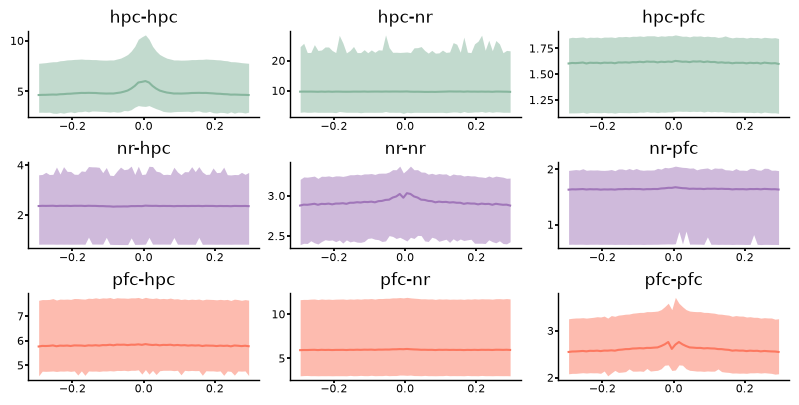

In [6]:
fig, ax = fma.plotting.makeFigure(n=(len(regs),len(regs)))
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        c = ccg_avg.sel(reg0=r0,reg1=r1)
        fma.plotting.semPlot(ccg_avg.t,c,color=isau.paperColors(r0),ax=ax[i,j])
        ax[i,j].set(title=f'{r0}-{r1}')

DO : show one example + compute peak delay as box !!

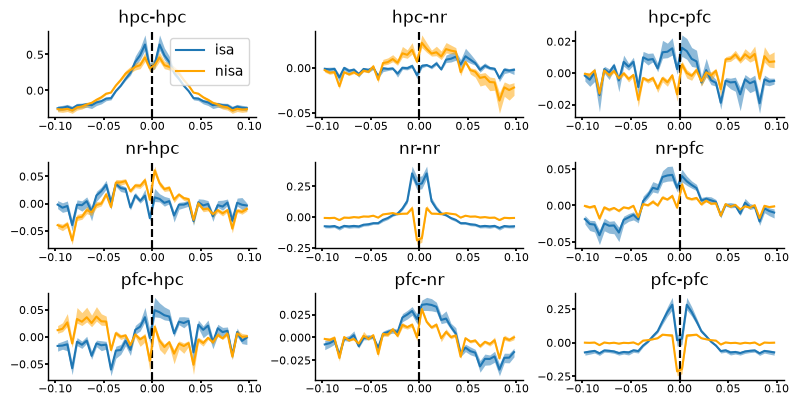

In [11]:
rat = 4
fig, ax = fma.plotting.makeFigure(n=(len(regs),len(regs)))
colors = ['tab:blue','orange']
for k, cond in enumerate(ccg_cat.cond.values):
    for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            c = ccg_cat.sel(cond=cond,rat=rat,reg0=r0,reg1=r1)
            c = c - c.mean(dim='t')
            ax[i,j].axvline(0,ls='--',color='k')
            fma.plotting.semPlot(ccg_cat.t,c,ax=ax[i,j],label=cond,color=colors[k])
            ax[i,j].set(title=f'{r0}-{r1}')
ax[0,0].legend();